In [6]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn openpyxl


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cs-training.csv')
print(df.shape)
df.head()

(150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [9]:
print(df['SeriousDlqin2yrs'].value_counts())
print("\nDefault Rate:", round(df['SeriousDlqin2yrs'].mean() * 100, 2), "%")

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default Rate: 6.68 %


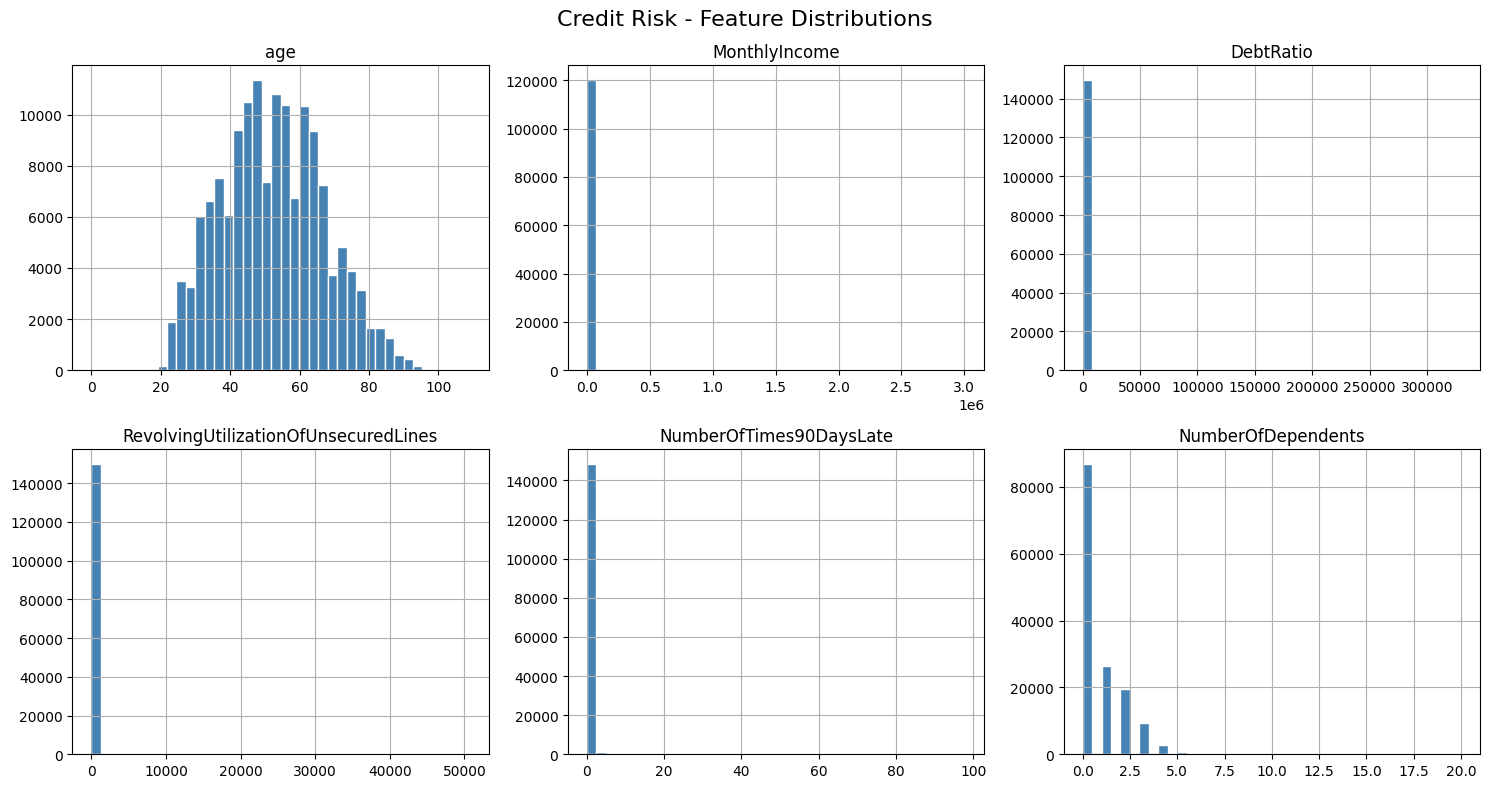

In [10]:
# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# Plot distribution of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Credit Risk - Feature Distributions', fontsize=16)

cols = ['age', 'MonthlyIncome', 'DebtRatio', 
        'RevolvingUtilizationOfUnsecuredLines',
        'NumberOfTimes90DaysLate', 'NumberOfDependents']

for i, col in enumerate(cols):
    ax = axes[i//3, i%3]
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [11]:
# 1. Fill missing values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# 2. Cap outliers at 99th percentile
cols_to_cap = ['MonthlyIncome', 'DebtRatio', 
               'RevolvingUtilizationOfUnsecuredLines',
               'NumberOfTimes90DaysLate']

for col in cols_to_cap:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# 3. Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nDataset shape:", df.shape)

Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Dataset shape: (150000, 11)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Separate features (X) and target (y)
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

# 2. Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nDefault rate in training set:", round(y_train.mean() * 100, 2), "%")
print("Default rate in testing set:", round(y_test.mean() * 100, 2), "%")

Training set size: (120000, 10)
Testing set size: (30000, 10)

Default rate in training set: 6.68 %
Default rate in testing set: 6.68 %


In [13]:
# Train Random Forest with class_weight balanced to handle imbalanced data
model = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees
    class_weight='balanced', # handles our 6.68% imbalance problem
    random_state=42,
    n_jobs=-1                # use all CPU cores to speed up
)

print("Training model... this may take 1-2 minutes")
model.fit(X_train, y_train)
print("✅ Model trained successfully!")

Training model... this may take 1-2 minutes
✅ Model trained successfully!


In [14]:
# Generate predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Model Performance
print("=" * 50)
print("MODEL PERFORMANCE REPORT")
print("=" * 50)
print("\n1. Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print("\n2. ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

print("\n3. Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

MODEL PERFORMANCE REPORT

1. Classification Report:
              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27995
     Default       0.56      0.15      0.24      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.57      0.60     30000
weighted avg       0.92      0.94      0.92     30000


2. ROC-AUC Score: 0.8355

3. Confusion Matrix:
[[27754   241]
 [ 1697   308]]


In [15]:
# Instead of default 0.5 threshold, use 0.3 to catch more defaulters
y_pred_tuned = (y_pred_proba >= 0.3).astype(int)

print("TUNED MODEL PERFORMANCE (threshold = 0.3)")
print("=" * 50)
print(classification_report(y_test, y_pred_tuned, 
      target_names=['No Default', 'Default']))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

print("\nConfusion Matrix:")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)

TUNED MODEL PERFORMANCE (threshold = 0.3)
              precision    recall  f1-score   support

  No Default       0.95      0.97      0.96     27995
     Default       0.43      0.36      0.40      2005

    accuracy                           0.93     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.93      0.92     30000

ROC-AUC Score: 0.8355

Confusion Matrix:
[[27039   956]
 [ 1276   729]]


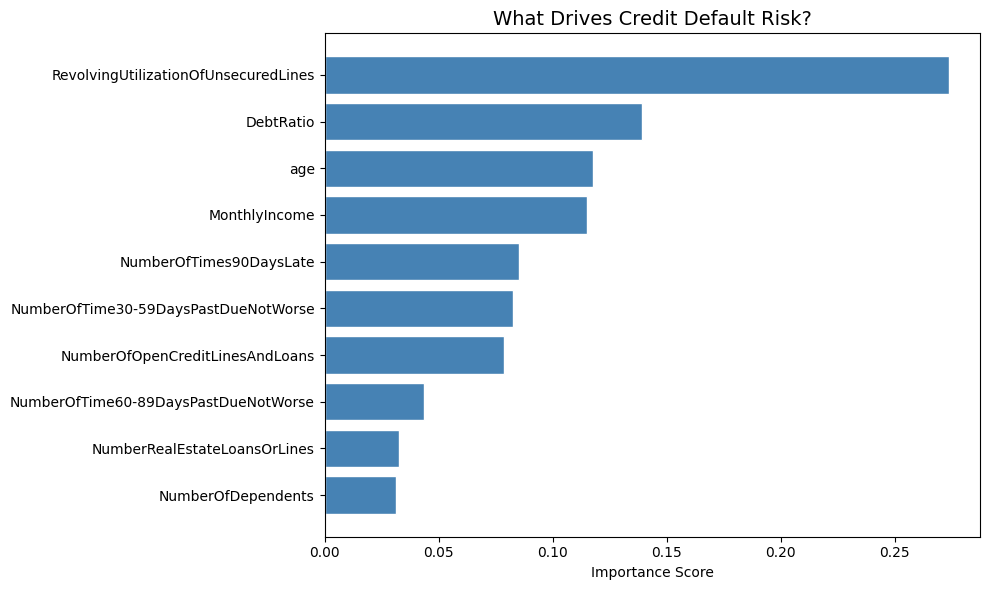

In [16]:
# Feature Importance Plot
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='steelblue', edgecolor='white')
plt.title('What Drives Credit Default Risk?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [18]:
# Create a results dataframe for Power BI
results = X_test.copy()
results['Actual_Default'] = y_test.values
results['Predicted_Default'] = y_pred_tuned
results['Default_Probability'] = y_pred_proba.round(4)
results['Risk_Tier'] = pd.cut(y_pred_proba, 
                               bins=[0, 0.1, 0.3, 0.6, 1.0],
                               labels=['Low', 'Medium', 'High', 'Very High'])

# Export to Excel for Power BI
results.to_excel('credit_risk_results.xlsx', index=False)
print("✅ Exported to credit_risk_results.xlsx")
print("\nRisk Tier Distribution:")
print(results['Risk_Tier'].value_counts())

✅ Exported to credit_risk_results.xlsx

Risk Tier Distribution:
Risk_Tier
Low          15062
Medium        3474
High          1318
Very High      280
Name: count, dtype: int64
